# Wilcoxon Signed-Rank Test: сравнение алгоритмов оптимизации портфеля

Сравниваются на одинаковых данных и `SIGMA_MAX`:
- **DEAP (GA)** — `Evo_code.ipynb`
- **GWO** — `GWO_fast_colab.ipynb`
- **Random search** — `optimize_random_return_under_risk`
- **LLM-as-optimizer** — `optimize_return_under_risk` с **`google/gemini-3.1-pro-preview`** (RouterAI)

30 paired-прогонов (один `seed` на `run_id`) → Wilcoxon по `mu_ann`. Результаты: `wilcoxon_experiment/`.

Для LLM ключ берётся из **`.env` в корне проекта** (`OPENAI_API_KEY`, RouterAI).

In [29]:
import json
import os
import random
import sys
import warnings
from pathlib import Path
from typing import Callable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path.cwd()
LLM_ROOT = ROOT / "llm-portfolio-optimizer-main"
LLM_PKG = LLM_ROOT / "trading_optimizer" / "src"
for p in (LLM_ROOT, LLM_PKG):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from llm_config import configure_llm_environment
from trading_optimizer.portfolio_return_optimizer import (
    optimize_random_return_under_risk,
    optimize_return_under_risk,
    portfolio_metrics_rolling,
)
from deap import algorithms, base, creator, tools

OUT_DIR = ROOT / "wilcoxon_experiment"
OUT_DIR.mkdir(exist_ok=True)

WINDOW = 252
TRADING_DAYS = 252
SIGMA_MAX = 0.25
CARDINALITY_K = 10
MIN_ASSETS = 3
MAX_ASSETS = 10
N_RUNS = 30
BASE_SEED = 42
SELECTION_SEED = BASE_SEED

EA_POP, EA_GEN = 80, 60
DEAP_VARIANTS = ["penalty", "penalty_cardinality", "death"]
GWO_N_ITER, GWO_N_WOLVES, ASSET_LIMIT = 35, 14, 25
BUDGET_RUB, TRANSACTION_COST, MIN_LOTS_PER_ASSET = 1_000_000, 0.0005, 1
LLM_N_PORTFOLIOS = 5000

# LLM-as-optimizer (mistralai/mistral-small-2603 via RouterAI)
LLM_MODEL = "mistralai/mistral-small-2603"
LLM_INITIAL_RANDOM_SAMPLES = 100
LLM_ITERATIONS = 50
LLM_CANDIDATES_PER_ITER = 3
LLM_ATTEMPTS_PER_ITER = 3

_env_path = ROOT / ".env"
configure_llm_environment(_env_path)
if not os.environ.get("OPENAI_API_KEY"):
    print(f"WARNING: OPENAI_API_KEY не найден в {_env_path}")
else:
    print(f"OPENAI_API_KEY загружен из {_env_path}")

print("OUT_DIR:", OUT_DIR.resolve(), "| SIGMA_MAX:", SIGMA_MAX, "| LLM:", LLM_MODEL)

OPENAI_API_KEY загружен из c:\Users\oklad\Desktop\Optimaze portfel\.env
OUT_DIR: C:\Users\oklad\Desktop\Optimaze portfel\wilcoxon_experiment | SIGMA_MAX: 0.25 | LLM: mistralai/mistral-small-2603


In [30]:
for fname in ("raw_dataset.parquet", "raw_absolute_prices.parquet", "assets_df.parquet"):
    if not (ROOT / fname).exists():
        raise FileNotFoundError(f"Нужен {ROOT / fname} (как в Evo_code.ipynb)")

prices = pd.read_parquet(ROOT / "raw_dataset.parquet")
prices_close = pd.read_parquet(ROOT / "raw_absolute_prices.parquet")
assets_df = pd.read_parquet(ROOT / "assets_df.parquet")

max_nan_share = 0.15
keep = prices.columns[prices.isna().mean() <= max_nan_share]
prices = prices[keep].dropna(how="all").ffill().dropna()
_last = prices.iloc[-1]
_has_inf = pd.Series(np.isinf(prices.to_numpy(dtype=float)).any(axis=0), index=prices.columns)
prices = prices.loc[:, (_last != 0) & (~_has_inf)]
prices_close = prices_close[prices.columns].ffill().dropna()
assets_df = assets_df.loc[prices.columns]
lot_size = (
    assets_df["LOTSIZE"].reindex(prices.columns).fillna(1).astype(int)
    if "LOTSIZE" in assets_df.columns
    else pd.Series(1, index=prices.columns, dtype=int)
)
print("Активов:", prices.shape[1], "| строк:", len(prices))

Активов: 42 | строк: 2387


In [31]:
_px = prices.astype(np.float64).replace(0, np.nan).ffill().bfill()
logret_df = np.log(_px / _px.shift(1)).replace([np.inf, -np.inf], np.nan).dropna(how="any")
EA_TICKERS = list(logret_df.columns)
EA_N = len(EA_TICKERS)
LOGRET_MAT = np.ascontiguousarray(logret_df.values.astype(np.float64))
rolling_cov = logret_df.rolling(WINDOW).cov()
eval_dates = logret_df.index[WINDOW - 1 :]
COV_TENSOR = np.empty((len(eval_dates), EA_N, EA_N), dtype=np.float64)
for ti, date in enumerate(eval_dates):
    block = rolling_cov.loc[date].loc[EA_TICKERS, EA_TICKERS].values.astype(np.float64)
    COV_TENSOR[ti] = np.nan_to_num(block, nan=0.0, posinf=0.0, neginf=0.0)


def metrics_from_weights_vec(w: np.ndarray) -> Tuple[float, float]:
    w = np.asarray(w, dtype=np.float64)
    s = w.sum()
    w = np.ones(EA_N) / EA_N if s <= 0 else w / s
    port_daily = LOGRET_MAT @ w
    mu_ann = float(np.nanmean(port_daily) * TRADING_DAYS)
    var_t = np.einsum("i,tij,j->t", w, COV_TENSOR, w) * TRADING_DAYS
    sigma_q_09 = float(np.nanquantile(np.sqrt(np.clip(var_t, 0.0, None)), 0.9))
    return mu_ann, sigma_q_09


def evaluate_weights_dict(weights: dict) -> dict:
    m = portfolio_metrics_rolling(weights, prices, window=WINDOW, trading_days=TRADING_DAYS)
    w = m["weights"]
    sigma_q = float(m["sigma_q_0.9"])
    return {
        "mu_ann": float(m["mu_ann"]),
        "sigma_q_0.9": sigma_q,
        "feasible": sigma_q <= SIGMA_MAX + 1e-9,
        "n_assets": int((w > 1e-8).sum()),
        "weights_json": json.dumps(w.to_dict(), ensure_ascii=False),
    }

In [32]:
def decode_weights(chrom) -> np.ndarray:
    w = np.clip(np.asarray(chrom, dtype=np.float64), 0.0, None)
    s = float(w.sum())
    return np.ones(EA_N) / EA_N if s <= 0 else w / s


def decode_topk(chrom, k: int = CARDINALITY_K) -> np.ndarray:
    w = decode_weights(chrom)
    if k >= EA_N:
        return w
    idx = np.argsort(-w)[:k]
    mask = np.zeros_like(w)
    mask[idx] = w[idx]
    s = float(mask.sum())
    return decode_weights(chrom) if s <= 0 else mask / s


def _deap_reset():
    for name in ("Individual", "FitnessMax"):
        if hasattr(creator, name):
            delattr(creator, name)


def make_eval_penalty(lam: float, use_topk: bool) -> Callable:
    def evaluate(ind):
        w = decode_topk(ind) if use_topk else decode_weights(ind)
        mu_ann, sig_q = metrics_from_weights_vec(w)
        return (mu_ann - lam * max(0.0, sig_q - SIGMA_MAX),)
    return evaluate


def make_eval_death() -> Callable:
    pen = -1e9
    def evaluate(ind):
        w = decode_weights(ind)
        mu_ann, sig_q = metrics_from_weights_vec(w)
        return (pen,) if sig_q > SIGMA_MAX else (mu_ann,)
    return evaluate


def build_seed_death(n_seeds: int = 8) -> List:
    singles = sorted(
        ((j, metrics_from_weights_vec(np.eye(EA_N)[j])[1]) for j in range(EA_N)),
        key=lambda x: x[1],
    )
    low_idx = [j for j, _ in singles[: max(5, CARDINALITY_K)]]
    out = []
    for j in low_idx[:5]:
        v = np.full(EA_N, 1e-6)
        v[j] = 1.0 - (EA_N - 1) * 1e-6
        out.append(creator.Individual(v.tolist()))
    v = np.full(EA_N, 1e-8)
    for j in low_idx[:CARDINALITY_K]:
        v[j] = 1.0
    out.append(creator.Individual((v / v.sum()).tolist()))
    while len(out) < n_seeds:
        out.append(creator.Individual([random.random() for _ in range(EA_N)]))
    return out[:n_seeds]


def run_deap_once(variant: str, seed: int) -> np.ndarray:
    _deap_reset()
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMax)
    use_topk = variant == "penalty_cardinality"
    evaluate = (
        make_eval_death() if variant == "death"
        else make_eval_penalty(10.0 * SIGMA_MAX, use_topk)
    )
    tb = base.Toolbox()
    tb.register("attr_float", random.random)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.attr_float, EA_N)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("evaluate", evaluate)
    tb.register("mate", tools.cxBlend, alpha=0.5)
    tb.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.05, indpb=1.0 / EA_N)
    tb.register("select", tools.selTournament, tournsize=3)
    random.seed(seed)
    np.random.seed(seed)
    init_pop = None
    if variant == "death":
        seeds = build_seed_death(min(12, EA_POP))
        rest = EA_POP - len(seeds)
        init_pop = seeds + (tb.population(n=rest) if rest > 0 else [])
    pop = init_pop if init_pop is not None else tb.population(n=EA_POP)
    hof = tools.HallOfFame(1)
    pop, _ = algorithms.eaSimple(pop, tb, cxpb=0.7, mutpb=0.3, ngen=EA_GEN, halloffame=hof, verbose=False)
    best = hof[0]
    return decode_topk(best) if use_topk else decode_weights(best)


def deap_to_metrics(w: np.ndarray) -> dict:
    wd = {EA_TICKERS[i]: float(w[i]) for i in range(EA_N) if w[i] > 1e-8}
    s = sum(wd.values())
    wd = {k: v / s for k, v in wd.items()}
    return evaluate_weights_dict(wd)

In [33]:
_px_all = prices.astype(np.float64).replace([0, np.inf, -np.inf], np.nan).ffill().bfill()
_ret_all = np.log(_px_all / _px_all.shift(1)).replace([np.inf, -np.inf], np.nan)
valid_cols = [
    c for c in _ret_all.columns
    if _ret_all[c].notna().mean() > 0.85
    and c in prices_close.columns
    and pd.notna(prices_close[c].ffill().iloc[-1])
]
_ret_valid = _ret_all[valid_cols].dropna(how="any")
_score = (_ret_valid.mean() * TRADING_DAYS) / (_ret_valid.std() * np.sqrt(TRADING_DAYS)).replace(0, np.nan)
OPT_TICKERS = list(_score.replace([np.inf, -np.inf], np.nan).fillna(-999).sort_values(ascending=False).head(ASSET_LIMIT).index)
OPT_N = len(OPT_TICKERS)
LOT_SIZE = lot_size.reindex(OPT_TICKERS).fillna(1).values.astype(int)
LAST_PRICE = prices_close.reindex(columns=OPT_TICKERS).ffill().iloc[-1].fillna(0).values
LOT_VALUE = LAST_PRICE * LOT_SIZE
VALID_ASSET_MASK = np.isfinite(LOT_VALUE) & (LOT_VALUE > 0)


def lots_to_weights(lots):
    values = lots.astype(float) * LOT_VALUE
    t = float(values.sum())
    return np.zeros(OPT_N) if t <= 0 else values / t


def portfolio_cost(lots):
    return float(np.dot(lots, LOT_VALUE)) * (1.0 + TRANSACTION_COST)


def repair_lots(lots):
    lots = np.asarray(lots, dtype=int).clip(min=0).copy()
    lots[~VALID_ASSET_MASK] = 0
    active = np.where(lots > 0)[0]
    if len(active) > CARDINALITY_K:
        keep = active[np.argsort(-lots[active] * LOT_VALUE[active])[:CARDINALITY_K]]
        mask = np.zeros(OPT_N, dtype=bool)
        mask[keep] = True
        lots[~mask] = 0
    if portfolio_cost(lots) > BUDGET_RUB > 0:
        lots = np.floor(lots * (BUDGET_RUB / portfolio_cost(lots) * 0.995)).astype(int)
    for _ in range(200):
        if portfolio_cost(lots) <= BUDGET_RUB or lots.sum() == 0:
            break
        active = np.where(lots > 0)[0]
        lots[active[np.argmax(lots[active] * LOT_VALUE[active])]] -= 1
    return lots


def position_to_lots(position):
    x = np.clip(np.nan_to_num(position, nan=0.0), 0.0, 1.0)
    x[~VALID_ASSET_MASK] = 0.0
    if float(x.sum()) <= 0:
        return np.zeros(OPT_N, dtype=int)
    active = np.argsort(-x)[:CARDINALITY_K]
    active = active[(x[active] > 0) & VALID_ASSET_MASK[active]]
    if len(active) == 0:
        return np.zeros(OPT_N, dtype=int)
    w = x[active] / x[active].sum()
    budget = BUDGET_RUB / (1.0 + TRANSACTION_COST)
    lots = np.zeros(OPT_N, dtype=int)
    for idx, wt in zip(active, w):
        lots[idx] = int(np.floor(budget * float(wt) / LOT_VALUE[idx]))
    for idx in active:
        if lots[idx] <= 0 and LOT_VALUE[idx] * (1.0 + TRANSACTION_COST) <= BUDGET_RUB:
            lots[idx] = MIN_LOTS_PER_ASSET
    return repair_lots(lots)


def lots_to_full_weights(lots: np.ndarray) -> dict:
    """Веса на полном универсуме EA_TICKERS для rolling-метрик."""
    w_sub = lots_to_weights(lots)
    wd = {OPT_TICKERS[i]: float(w_sub[i]) for i in range(OPT_N) if w_sub[i] > 1e-8}
    w_full = {t: wd.get(t, 0.0) for t in EA_TICKERS}
    s = sum(w_full.values())
    if s <= 0:
        return {}
    return {k: v / s for k, v in w_full.items() if v > 0}


def lots_to_weight_vec(lots: np.ndarray) -> np.ndarray:
    wd = lots_to_full_weights(lots)
    w = np.zeros(EA_N, dtype=np.float64)
    for t, v in wd.items():
        w[EA_TICKERS.index(t)] = v
    return w


def objective_lots_rolling(lots: np.ndarray) -> Tuple[float, float, float, bool]:
    """Цель GWO: тот же rolling sigma_q_0.9 и score, что у LLM/DEAP."""
    lots = repair_lots(np.asarray(lots, dtype=int))
    if lots.sum() == 0 or portfolio_cost(lots) > BUDGET_RUB + 1e-9:
        return -1e9, 0.0, 1e9, False
    w = lots_to_weight_vec(lots)
    if w.sum() <= 0:
        return -1e9, 0.0, 1e9, False
    mu_ann, sig_q = metrics_from_weights_vec(w)
    viol = max(0.0, sig_q - SIGMA_MAX)
    conc = float(np.sum(w * w))
    score = mu_ann - 20.0 * viol - 0.02 * conc
    feasible = sig_q <= SIGMA_MAX + 1e-9 and int((w > 1e-8).sum()) <= CARDINALITY_K
    return float(score), float(mu_ann), float(sig_q), bool(feasible)


def run_gwo_once(seed: int) -> dict:
    rng = np.random.default_rng(seed)
    wolves = rng.random((GWO_N_WOLVES, OPT_N))
    wolves[:, ~VALID_ASSET_MASK] = 0.0
    alpha_pos = beta_pos = delta_pos = wolves[0].copy()
    alpha_score = beta_score = delta_score = -np.inf
    alpha_lots = position_to_lots(alpha_pos)
    best_feas_lots, best_feas_score = None, -np.inf
    for it in range(GWO_N_ITER + 1):
        for i in range(GWO_N_WOLVES):
            lots_i = position_to_lots(wolves[i])
            score_i, mu_i, sig_i, feas_i = objective_lots_rolling(lots_i)
            if feas_i and score_i > best_feas_score:
                best_feas_score, best_feas_lots = score_i, lots_i.copy()
            if score_i > alpha_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = alpha_score, alpha_pos.copy()
                alpha_score, alpha_pos = score_i, wolves[i].copy()
                alpha_lots = lots_i.copy()
            elif score_i > beta_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = score_i, wolves[i].copy()
            elif score_i > delta_score:
                delta_score, delta_pos = score_i, wolves[i].copy()
        a = 2.0 - 2.0 * (it / max(1, GWO_N_ITER))
        for i in range(GWO_N_WOLVES):
            r1, r2 = rng.random(OPT_N), rng.random(OPT_N)
            X1 = alpha_pos - (2 * a * r1 - a) * np.abs(2 * r2 * alpha_pos - wolves[i])
            r1, r2 = rng.random(OPT_N), rng.random(OPT_N)
            X2 = beta_pos - (2 * a * r1 - a) * np.abs(2 * r2 * beta_pos - wolves[i])
            r1, r2 = rng.random(OPT_N), rng.random(OPT_N)
            X3 = delta_pos - (2 * a * r1 - a) * np.abs(2 * r2 * delta_pos - wolves[i])
            wolves[i] = np.clip((X1 + X2 + X3) / 3.0, 0.0, 1.0)
            wolves[i, ~VALID_ASSET_MASK] = 0.0
    # Если alpha не feasible по rolling sigma_q_0.9 — берём лучший feasible за прогон.
    _, _, sig_alpha, feas_alpha = objective_lots_rolling(alpha_lots)
    if best_feas_lots is not None and not feas_alpha:
        alpha_lots = best_feas_lots
    w_full = lots_to_full_weights(alpha_lots)
    m = evaluate_weights_dict(w_full)
    m["algorithm"] = "gwo"
    m["gwo_score_rolling"] = float(objective_lots_rolling(alpha_lots)[0])
    return m


def run_llm_random_once(seed: int) -> dict:
    best, _ = optimize_random_return_under_risk(
        prices=prices,
        n_portfolios=LLM_N_PORTFOLIOS,
        min_assets=MIN_ASSETS,
        max_assets=MAX_ASSETS,
        max_sigma_ann=SIGMA_MAX,
        rolling_window=WINDOW,
        trading_days=TRADING_DAYS,
        seed=seed,
        collect_history=False,
    )
    m = evaluate_weights_dict(best.weights)
    m["algorithm"] = "llm_random"
    m["score_train"] = float(best.score)
    return m


def run_llm_gemini_once(seed: int) -> dict:
    """LLM-as-optimizer: итеративная генерация кандидатов через Gemini."""
    best, _ = optimize_return_under_risk(
        prices=prices,
        min_assets=MIN_ASSETS,
        max_assets=MAX_ASSETS,
        max_sigma_ann=SIGMA_MAX,
        rolling_window=WINDOW,
        trading_days=TRADING_DAYS,
        seed=seed,
        model=LLM_MODEL,
        initial_random_samples=LLM_INITIAL_RANDOM_SAMPLES,
        iterations=LLM_ITERATIONS,
        candidates_per_iter=LLM_CANDIDATES_PER_ITER,
        llm_attempts_per_iteration=LLM_ATTEMPTS_PER_ITER,
        verbose=False,
        progress=True,
    )
    m = evaluate_weights_dict(best.weights)
    m["algorithm"] = "llm_gemini"
    m["model"] = LLM_MODEL
    m["score_train"] = float(best.score)
    return m

## 1. Отбор лучшего варианта DEAP

In [34]:
selection_rows = []
best_deap_variant, best_deap_mu, best_deap_feas = None, -np.inf, False

for variant in DEAP_VARIANTS:
    w = run_deap_once(variant, SELECTION_SEED)
    m = deap_to_metrics(w)
    row = {"family": "deap", "variant": variant, **m}
    selection_rows.append(row)
    better = (m["feasible"] and not best_deap_feas) or (
        m["feasible"] == best_deap_feas and m["mu_ann"] > best_deap_mu
    )
    if better:
        best_deap_variant, best_deap_mu, best_deap_feas = variant, m["mu_ann"], m["feasible"]

BEST_DEAP_VARIANT = best_deap_variant
selection_rows.append({**run_gwo_once(SELECTION_SEED), "family": "gwo", "variant": "grey_wolf_optimizer_fast"})
selection_rows.append({**run_llm_random_once(SELECTION_SEED), "family": "llm", "variant": "random_search"})
print("LLM Gemini selection run...")
selection_rows.append({**run_llm_gemini_once(SELECTION_SEED), "family": "llm", "variant": LLM_MODEL})

selection_df = pd.DataFrame(selection_rows)
selection_df.to_csv(OUT_DIR / "selection_best_variants.csv", index=False)
with open(OUT_DIR / "selected_config.json", "w", encoding="utf-8") as f:
    json.dump({
        "SIGMA_MAX": SIGMA_MAX,
        "WINDOW": WINDOW,
        "BEST_DEAP_VARIANT": BEST_DEAP_VARIANT,
        "LLM_MODEL": LLM_MODEL,
        "LLM_ITERATIONS": LLM_ITERATIONS,
        "N_RUNS": N_RUNS,
        "BASE_SEED": BASE_SEED,
    }, f, indent=2, ensure_ascii=False)
print("BEST_DEAP_VARIANT:", BEST_DEAP_VARIANT)
display(selection_df)

LLM Gemini selection run...
iter=1/50 requesting candidates...
iter=1/50 accepted=3/3 best=-0.2266
iter=2/50 requesting candidates...
iter=2/50 accepted=3/3 best=-0.1218
iter=3/50 requesting candidates...
iter=3/50 accepted=3/3 best=0.0618
iter=4/50 requesting candidates...
iter=4/50 accepted=3/3 best=0.0618
iter=5/50 requesting candidates...
iter=5/50 accepted=3/3 best=0.0741
iter=6/50 requesting candidates...
iter=6/50 accepted=3/3 best=0.0770
iter=7/50 requesting candidates...
iter=7/50 accepted=3/3 best=0.0770
iter=8/50 requesting candidates...
iter=8/50 accepted=3/3 best=0.0770
iter=9/50 requesting candidates...
iter=9/50 accepted=3/3 best=0.0770
iter=10/50 requesting candidates...
iter=10/50 accepted=3/3 best=0.0770
iter=11/50 requesting candidates...
iter=11/50 accepted=3/3 best=0.0963
iter=12/50 requesting candidates...
iter=12/50 accepted=3/3 best=0.0963
iter=13/50 requesting candidates...
iter=13/50 accepted=3/3 best=0.0963
iter=14/50 requesting candidates...
iter=14/50 accep

,family,variant,mu_ann,sigma_q_0.9,feasible,n_assets,weights_json,algorithm,gwo_score_rolling,score_train,model
0,deap,penalty,0.137243,0.248727,True,15,"{""LKOH"": 0.0029153367825011166, ""ROSN"": 0.0031...",NaN,NaN,NaN,NaN
1,deap,penalty_cardinality,0.133134,0.249996,True,10,"{""GMKN"": 0.07405721707514769, ""PLZL"": 0.079093...",NaN,NaN,NaN,NaN
2,deap,death,0.015165,0.310910,False,42,"{""SBER"": 1e-06, ""SBERP"": 1e-06, ""GAZP"": 1e-06,...",NaN,NaN,NaN,NaN
3,gwo,grey_wolf_optimizer_fast,0.112469,0.278386,False,10,"{""GMKN"": 0.07804386865364978, ""NLMK"": 0.074337...",gwo,-0.45773,NaN,NaN
4,llm,random_search,0.109381,0.236351,True,4,"{""TATNP"": 0.1848186641235236, ""CHMF"": 0.232304...",llm_random,NaN,0.104171,NaN
5,llm,mistralai/mistral-small-2603,0.121784,0.243419,True,9,"{""USD000UTSTOM"": 0.22772277227722773, ""MAGN"": ...",llm_gemini,NaN,0.119174,mistralai/mistral-small-2603


## 2. Тридцать прогонов (paired seeds)

In [35]:
run_rows = []
for run_id in range(N_RUNS):
    seed = BASE_SEED + run_id
    print(f"Run {run_id + 1}/{N_RUNS}, seed={seed}")
    m_deap = deap_to_metrics(run_deap_once(BEST_DEAP_VARIANT, seed))
    m_deap.update({"algorithm": "deap", "variant": BEST_DEAP_VARIANT, "run_id": run_id, "seed": seed})
    run_rows.append(m_deap)
    m_gwo = run_gwo_once(seed)
    m_gwo.update({"run_id": run_id, "seed": seed})
    run_rows.append(m_gwo)
    m_llm = run_llm_random_once(seed)
    m_llm.update({"run_id": run_id, "seed": seed})
    run_rows.append(m_llm)
    m_gemini = run_llm_gemini_once(seed)
    m_gemini.update({"run_id": run_id, "seed": seed})
    run_rows.append(m_gemini)

runs_df = pd.DataFrame(run_rows)
runs_df.to_csv(OUT_DIR / "runs_30x4.csv", index=False)
print("Saved:", OUT_DIR / "runs_30x4.csv")
display(runs_df.groupby("algorithm")[["mu_ann", "sigma_q_0.9", "feasible"]].agg(["mean", "std", "sum"]))

Run 1/30, seed=42
iter=1/50 requesting candidates...
iter=1/50 accepted=3/3 best=-0.1975
iter=2/50 requesting candidates...
iter=2/50 accepted=3/3 best=-0.1975
iter=3/50 requesting candidates...
iter=3/50 accepted=3/3 best=-0.1975
iter=4/50 requesting candidates...
iter=4/50 accepted=3/3 best=-0.1975
iter=5/50 requesting candidates...
iter=5/50 accepted=3/3 best=-0.1975
iter=6/50 requesting candidates...
iter=6/50 accepted=3/3 best=-0.1975
iter=7/50 requesting candidates...
iter=7/50 accepted=3/3 best=-0.0707
iter=8/50 requesting candidates...
iter=8/50 accepted=3/3 best=-0.0707
iter=9/50 requesting candidates...
iter=9/50 accepted=3/3 best=-0.0707
iter=10/50 requesting candidates...
iter=10/50 accepted=3/3 best=0.0672
iter=11/50 requesting candidates...
iter=11/50 accepted=3/3 best=0.0765
iter=12/50 requesting candidates...
iter=12/50 accepted=3/3 best=0.0765
iter=13/50 requesting candidates...
iter=13/50 accepted=3/3 best=0.0765
iter=14/50 requesting candidates...
iter=14/50 accepted

mu_ann                     sigma_q_0.9                      \
                mean       std       sum        mean       std       sum   
algorithm                                                                  
deap        0.149094  0.010831  4.472822    0.249574  0.000900  7.487207   
gwo         0.106104  0.004974  3.183123    0.278975  0.003752  8.369264   
llm_gemini  0.114217  0.019981  3.426519    0.242265  0.007034  7.267962   
llm_random  0.105373  0.013805  3.161181    0.238739  0.009360  7.162163   

            feasible                
                mean       std sum  
algorithm                           
deap        0.566667  0.504007  17  
gwo         0.000000  0.000000   0  
llm_gemini  0.966667  0.182574  29  
llm_random  0.966667  0.182574  29

## 3. Wilcoxon Signed-Rank Test

,algo_a,algo_b,n_pairs,mean_mu_a,mean_mu_b,mean_diff_a_minus_b,median_diff,wilcoxon_statistic,p_value,significant_5pct
0,deap,gwo,30,0.149094,0.106104,0.042990,0.045124,0.0,1.862645e-09,True
1,deap,llm_random,30,0.149094,0.105373,0.043721,0.043981,2.0,5.587935e-09,True
2,deap,llm_gemini,30,0.149094,0.114217,0.034877,0.037333,6.0,2.607703e-08,True
3,gwo,llm_random,30,0.106104,0.105373,0.000731,0.002504,192.0,4.161299e-01,False
4,gwo,llm_gemini,30,0.106104,0.114217,-0.008113,-0.008746,134.0,4.265171e-02,True
5,llm_random,llm_gemini,30,0.105373,0.114217,-0.008845,-0.012057,137.0,4.971012e-02,True


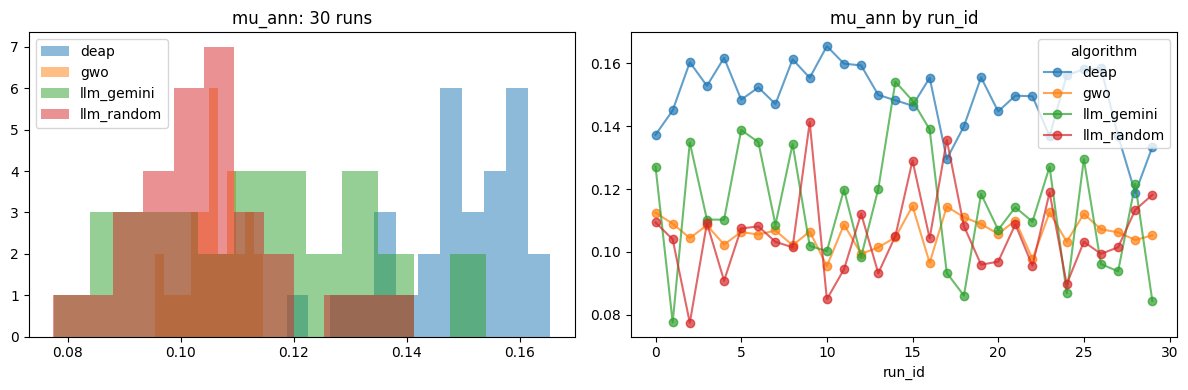

In [36]:
def wilcoxon_pair(df, algo_a, algo_b):
    a = df[df["algorithm"] == algo_a].sort_values("run_id")["mu_ann"].to_numpy()
    b = df[df["algorithm"] == algo_b].sort_values("run_id")["mu_ann"].to_numpy()
    stat, pval = stats.wilcoxon(a, b, alternative="two-sided", zero_method="wilcox")
    diff = a - b
    return {
        "algo_a": algo_a, "algo_b": algo_b, "n_pairs": len(a),
        "mean_mu_a": float(a.mean()), "mean_mu_b": float(b.mean()),
        "mean_diff_a_minus_b": float(diff.mean()), "median_diff": float(np.median(diff)),
        "wilcoxon_statistic": float(stat), "p_value": float(pval),
        "significant_5pct": bool(pval < 0.05),
    }

ALGORITHMS = ["deap", "gwo", "llm_random", "llm_gemini"]
pairs = [
    ("deap", "gwo"),
    ("deap", "llm_random"),
    ("deap", "llm_gemini"),
    ("gwo", "llm_random"),
    ("gwo", "llm_gemini"),
    ("llm_random", "llm_gemini"),
]
wilcoxon_df = pd.DataFrame([wilcoxon_pair(runs_df, a, b) for a, b in pairs])
wilcoxon_df.to_csv(OUT_DIR / "wilcoxon_results.csv", index=False)
display(wilcoxon_df)

pivot = runs_df.pivot(index="run_id", columns="algorithm", values="mu_ann")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for algo, sub in runs_df.groupby("algorithm"):
    axes[0].hist(sub["mu_ann"], bins=12, alpha=0.5, label=algo)
axes[0].set_title("mu_ann: 30 runs"); axes[0].legend()
pivot.plot(ax=axes[1], marker="o", alpha=0.7)
axes[1].set_title("mu_ann by run_id")
plt.tight_layout()
plt.savefig(OUT_DIR / "mu_ann_plot.png", dpi=120)
plt.show()

**Интерпретация:** p < 0.05 — медиана парной разности `mu_ann` отлична от нуля.

- `llm_random` — случайный перебор без API.
- `llm_gemini` — `optimize_return_under_risk` (нужен `OPENAI_API_KEY` / RouterAI).
- **GWO** — в цикле и в отчёте один и тот же rolling `sigma_q_0.9` (окно `WINDOW`), score как у LLM: `mu_ann - 20·risk_violation - 0.02·concentration`.
- Итоговый `mu_ann` для всех методов — `portfolio_metrics_rolling`.